<a href="https://colab.research.google.com/github/parksuejin1026/2026_BDA_Study/blob/main/Assignment/bigdata_publicdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 산업규모별 임금 및 근로시간 데이터 분석

이 노트북은 2026년 1월 `산업규모별임금및근로시간.csv` 공공데이터를 사용해 산업별·사업체 규모별 임금과 근로시간 차이를 비교한다.


In [22]:
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 51.8 MB/s eta 0:00:00


In [23]:
from pathlib import Path
import platform

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. 데이터 불러오기

CSV 파일은 `cp949` 인코딩이며, 첫 번째 행에 실제 지표명이 들어 있다. 노트북 위치가 바뀌어도 실행되도록 현재 폴더의 CSV 파일을 자동으로 찾는다.


In [24]:
csv_name = '산업규모별임금및근로시간.csv'
candidate_paths = [
    Path.cwd() / csv_name,
    Path.cwd() / 'Assignment' / csv_name,
]

csv_path = next((path for path in candidate_paths if path.exists()), None)
if csv_path is None:
    found_paths = list(Path.cwd().rglob(csv_name))
    if not found_paths:
        raise FileNotFoundError(f'{csv_name} 파일을 찾을 수 없습니다. 현재 작업 폴더: {Path.cwd()}')
    csv_path = found_paths[0]

raw = pd.read_csv(csv_path, encoding='cp949')
print(f'데이터 파일: {csv_path}')
raw.head()


데이터 파일: /content/산업규모별임금및근로시간.csv


,산업분류,규모별,2026.01,2026.01.1,2026.01.2,2026.01.3,2026.01.4,2026.01.5,2026.01.6,2026.01.7,2026.01.8,2026.01.9,2026.01.10,2026.01.11,2026.01.12,2026.01.13
0,산업분류,규모별,전체근로일수 (일),상용근로일수 (일),임시일용근로일수 (일),전체근로시간 (시간),상용총근로시간 (시간),상용소정실근로시간 (시간),상용초과근로시간 (시간),임시일용근로시간 (시간),전체임금총액 (원),상용임금총액 (원),상용정액급여 (원),상용초과급여 (원),상용특별급여 (원),임시일용임금총액 (원)
1,전체,전규모(1인이상),19.7,20.5,12.6,158.0,165.4,158.0,7.4,90.6,4588273,4889948,3799129,240874,849945,1817449
2,전체,-5인이상,19.8,20.4,12.8,160.6,166.3,157.6,8.7,96.7,5020530,5276360,3989766,285524,1001070,2127195
3,전체,-10인이상,19.8,20.3,13.2,161.6,166.6,156.8,9.8,101.5,5320707,5575212,4102634,326021,1146556,2225106
4,전체,-30인이상,19.8,20.1,14.5,163.4,166.5,155.5,11.1,113.8,6001275,6228861,4323601,388445,1516815,2446246


In [25]:
print(f'원본 데이터 크기: {raw.shape[0]}행 x {raw.shape[1]}열')
raw.iloc[:2]


원본 데이터 크기: 253행 x 16열


,산업분류,규모별,2026.01,2026.01.1,2026.01.2,2026.01.3,2026.01.4,2026.01.5,2026.01.6,2026.01.7,2026.01.8,2026.01.9,2026.01.10,2026.01.11,2026.01.12,2026.01.13
0,산업분류,규모별,전체근로일수 (일),상용근로일수 (일),임시일용근로일수 (일),전체근로시간 (시간),상용총근로시간 (시간),상용소정실근로시간 (시간),상용초과근로시간 (시간),임시일용근로시간 (시간),전체임금총액 (원),상용임금총액 (원),상용정액급여 (원),상용초과급여 (원),상용특별급여 (원),임시일용임금총액 (원)
1,전체,전규모(1인이상),19.7,20.5,12.6,158.0,165.4,158.0,7.4,90.6,4588273,4889948,3799129,240874,849945,1817449


## 2. 데이터 정리

원본은 첫 행이 컬럼명처럼 들어가 있으므로 첫 행을 컬럼명으로 올리고, 공백이 섞인 규모명을 정리한 뒤 수치형 지표를 숫자로 변환한다.


In [26]:
# 첫 번째 데이터 행을 실제 컬럼명으로 사용한다.
df = raw.iloc[1:].copy()
df.columns = raw.iloc[0].tolist()
df.columns.name = None
df = df.reset_index(drop=True)

# 규모별 값 앞뒤에 붙은 공백과 하이픈 표기 차이를 정리한다.
df['규모별'] = df['규모별'].str.strip().str.lstrip('-')

# 산업분류와 규모별을 제외한 지표 컬럼은 모두 숫자형으로 변환한다.
numeric_cols = df.columns[2:]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df.head()


,산업분류,규모별,전체근로일수 (일),상용근로일수 (일),임시일용근로일수 (일),전체근로시간 (시간),상용총근로시간 (시간),상용소정실근로시간 (시간),상용초과근로시간 (시간),임시일용근로시간 (시간),전체임금총액 (원),상용임금총액 (원),상용정액급여 (원),상용초과급여 (원),상용특별급여 (원),임시일용임금총액 (원)
0,전체,전규모(1인이상),19.7,20.5,12.6,158.0,165.4,158.0,7.4,90.6,"4,588,273.0","4,889,948.0","3,799,129.0","240,874.0","849,945.0","1,817,449.0"
1,전체,5인이상,19.8,20.4,12.8,160.6,166.3,157.6,8.7,96.7,"5,020,530.0","5,276,360.0","3,989,766.0","285,524.0","1,001,070.0","2,127,195.0"
2,전체,10인이상,19.8,20.3,13.2,161.6,166.6,156.8,9.8,101.5,"5,320,707.0","5,575,212.0","4,102,634.0","326,021.0","1,146,556.0","2,225,106.0"
3,전체,30인이상,19.8,20.1,14.5,163.4,166.5,155.5,11.1,113.8,"6,001,275.0","6,228,861.0","4,323,601.0","388,445.0","1,516,815.0","2,446,246.0"
4,전체,1~9인,19.6,20.9,11.9,150.7,162.7,160.6,2.2,78.9,"3,097,108.0","3,384,966.0","3,132,567.0","53,874.0","198,525.0","1,377,815.0"


In [27]:
print('정리 후 컬럼 목록')
display(pd.DataFrame({'컬럼명': df.columns}))

print('규모별 표기 정리 결과')
display(pd.DataFrame({'규모별': df['규모별'].unique()}))


정리 후 컬럼 목록


,컬럼명
0,산업분류
1,규모별
2,전체근로일수 (일)
3,상용근로일수 (일)
4,임시일용근로일수 (일)
5,전체근로시간 (시간)
6,상용총근로시간 (시간)
7,상용소정실근로시간 (시간)
8,상용초과근로시간 (시간)
9,임시일용근로시간 (시간)


규모별 표기 정리 결과


,규모별
0,전규모(1인이상)
1,5인이상
2,10인이상
3,30인이상
4,1~9인
5,1~29인
6,1~299인
7,5~299인
8,1~4인
9,5~9인


In [ ]:
data_check = pd.DataFrame({
    '항목': ['행 수', '열 수', '산업분류 수', '규모 구분 수', '결측치 수'],
    '값': [
        df.shape[0],
        df.shape[1],
        df['산업분류'].nunique(),
        df['규모별'].nunique(),
        int(df.isna().sum().sum()),
    ]
})

data_check


,항목,값
0,행 수,252
1,열 수,16
2,산업분류 수,18
3,규모 구분 수,14
4,결측치 수,47


In [29]:
# 누적 규모 구간과 실제 규모 구간이 함께 있으므로, 분석 목적에 맞게 구분해서 사용한다.
display(df['산업분류'].value_counts().to_frame('행 수').head())
display(pd.DataFrame({'규모별 구분': df['규모별'].unique()}))


,행 수
산업분류,
전체,14
B.광업(05~08),14
C.제조업(10~34),14
"D.전기, 가스, 증기 및 공기 조절 공급업(35)",14
"E.수도, 하수 및 폐기물 처리, 원료 재생업(36~39)",14


,규모별 구분
0,전규모(1인이상)
1,5인이상
2,10인이상
3,30인이상
4,1~9인
5,1~29인
6,1~299인
7,5~299인
8,1~4인
9,5~9인


In [30]:
missing = df.isna().sum().to_frame('결측치 수')
missing[missing['결측치 수'] > 0]


,결측치 수
전체근로일수 (일),3
상용근로일수 (일),3
임시일용근로일수 (일),4
전체근로시간 (시간),3
상용총근로시간 (시간),3
상용소정실근로시간 (시간),3
상용초과근로시간 (시간),3
임시일용근로시간 (시간),4
전체임금총액 (원),3
상용임금총액 (원),3


## 3. 전체 현황

`산업분류 = 전체`, `규모별 = 전규모(1인이상)` 행을 기준으로 전체 사업체의 대표값을 확인한다.

In [31]:
# 전체 산업, 전규모 행을 기준선으로 사용한다.
overall = df[(df['산업분류'] == '전체') & (df['규모별'] == '전규모(1인이상)')]
overall.T


,0
산업분류,전체
규모별,전규모(1인이상)
전체근로일수 (일),19.7
상용근로일수 (일),20.5
임시일용근로일수 (일),12.6
전체근로시간 (시간),158.0
상용총근로시간 (시간),165.4
상용소정실근로시간 (시간),158.0
상용초과근로시간 (시간),7.4
임시일용근로시간 (시간),90.6


In [ ]:
key_cols = [
    '전체근로시간 (시간)',
    '상용초과근로시간 (시간)',
    '전체임금총액 (원)',
    '상용정액급여 (원)',
    '상용초과급여 (원)',
    '상용특별급여 (원)',
]

df[key_cols].describe()


,전체근로시간 (시간),상용초과근로시간 (시간),전체임금총액 (원),상용정액급여 (원),상용초과급여 (원),상용특별급여 (원)
count,249.0,249.0,249.0,249.0,249.0,247.0
mean,159.0,6.8,"4,574,353.4","3,942,665.6","226,771.7","630,297.1"
std,11.5,5.1,"1,839,693.5","960,384.6","182,349.0","970,742.6"
min,124.9,0.0,"2,087,408.0","2,511,554.0","1,304.0","3,762.0"
25%,154.3,2.9,"3,254,522.0","3,183,806.0","86,241.0","141,763.5"
50%,161.3,5.7,"4,172,939.0","3,816,866.0","184,052.0","262,350.0"
75%,165.3,9.6,"5,241,077.0","4,474,440.0","325,885.0","573,706.0"
max,183.8,23.7,"12,925,761.0","7,092,251.0","926,108.0","7,141,973.0"


## 4. 산업별 비교

산업별 비교에서는 규모 조건이 섞이지 않도록 각 산업의 `전규모(1인이상)` 행만 사용한다.

In [ ]:
industry_df = df[(df['산업분류'] != '전체') & (df['규모별'] == '전규모(1인이상)')].copy()

industry_df['시간당임금_단순추정'] = industry_df['전체임금총액 (원)'] / industry_df['전체근로시간 (시간)']
industry_df['특별급여비중(%)'] = industry_df['상용특별급여 (원)'] / industry_df['상용임금총액 (원)'] * 100
industry_df['초과근로비중(%)'] = industry_df['상용초과근로시간 (시간)'] / industry_df['상용총근로시간 (시간)'] * 100

industry_summary = industry_df[[
    '산업분류',
    '전체근로시간 (시간)',
    '상용초과근로시간 (시간)',
    '초과근로비중(%)',
    '전체임금총액 (원)',
    '상용정액급여 (원)',
    '상용초과급여 (원)',
    '상용특별급여 (원)',
    '특별급여비중(%)',
    '시간당임금_단순추정',
]]

industry_summary.sort_values('전체임금총액 (원)', ascending=False).head(10)

,산업분류,전체근로시간 (시간),상용초과근로시간 (시간),초과근로비중(%),전체임금총액 (원),상용정액급여 (원),상용초과급여 (원),상용특별급여 (원),특별급여비중(%),시간당임금_단순추정
140,K.금융 및 보험업(64~66),162.3,4.0,2.5,"9,356,866.0","5,924,300.0","170,337.0","3,383,842.0",35.7,"57,651.7"
168,"M.전문, 과학 및 기술 서비스업(70~73)",161.8,5.1,3.1,"6,446,026.0","4,882,636.0","181,723.0","1,491,438.0",22.7,"39,839.5"
42,"D.전기, 가스, 증기 및 공기 조절 공급업(35)",161.5,7.6,4.7,"6,297,369.0","5,470,481.0","413,800.0","486,916.0",7.6,"38,993.0"
126,J.정보통신업(58~63),163.2,6.4,3.9,"5,966,397.0","4,857,133.0","232,642.0","1,011,524.0",16.6,"36,558.8"
28,C.제조업(10~34),172.1,15.4,8.8,"5,909,584.0","3,929,230.0","471,399.0","1,647,395.0",27.2,"34,338.1"
14,B.광업(05~08),168.3,13.2,7.5,"4,971,457.0","4,682,651.0","421,525.0","67,715.0",1.3,"29,539.3"
98,H.운수 및 창고업(49~52),161.2,10.3,6.2,"4,448,905.0","3,797,792.0","393,102.0","455,559.0",9.8,"27,598.7"
84,G.도매 및 소매업(45~47),161.6,4.6,2.7,"4,392,541.0","3,916,127.0","124,048.0","619,254.0",13.3,"27,181.6"
56,"E.수도, 하수 및 폐기물 처리, 원료 재생업(36~39)",175.5,13.7,7.6,"4,363,126.0","3,840,887.0","420,139.0","233,889.0",5.2,"24,861.1"
196,P.교육 서비스업(85),137.7,1.8,1.3,"3,969,727.0","3,841,541.0","48,195.0","221,519.0",5.4,"28,828.8"


In [34]:
print('전체임금총액 하위 5개 산업')
display(industry_summary.sort_values('전체임금총액 (원)').head(5))

print('전체근로시간 상위 5개 산업')
display(industry_summary.sort_values('전체근로시간 (시간)', ascending=False).head(5))

print('단순 시간당임금 상위 5개 산업')
display(industry_summary.sort_values('시간당임금_단순추정', ascending=False).head(5))


전체임금총액 하위 5개 산업


,산업분류,전체근로시간 (시간),상용초과근로시간 (시간),초과근로비중(%),전체임금총액 (원),상용정액급여 (원),상용초과급여 (원),상용특별급여 (원),특별급여비중(%),시간당임금_단순추정
112,I.숙박 및 음식점업(55~56),142.8,6.6,3.9,"2,409,376.0","2,684,242.0","147,409.0","134,730.0",4.5,"16,872.4"
182,"N.사업시설 관리, 사업 지원 및 임대 서비스업(74~76)",159.0,5.1,3.1,"2,961,949.0","2,733,013.0","175,604.0","208,399.0",6.7,"18,628.6"
154,L.부동산업(68),167.9,1.1,0.7,"3,124,328.0","3,051,824.0","64,852.0","53,248.0",1.7,"18,608.3"
210,Q.보건업 및 사회복지 서비스업(86~87),149.2,4.4,2.8,"3,320,034.0","3,146,808.0","174,067.0","162,011.0",4.7,"22,252.2"
238,"S.협회 및 단체, 수리 및 기타 개인 서비스업(94~96)",160.6,3.4,2.1,"3,366,929.0","3,084,328.0","92,910.0","307,255.0",8.8,"20,964.7"


전체근로시간 상위 5개 산업


,산업분류,전체근로시간 (시간),상용초과근로시간 (시간),초과근로비중(%),전체임금총액 (원),상용정액급여 (원),상용초과급여 (원),상용특별급여 (원),특별급여비중(%),시간당임금_단순추정
56,"E.수도, 하수 및 폐기물 처리, 원료 재생업(36~39)",175.5,13.7,7.6,"4,363,126.0","3,840,887.0","420,139.0","233,889.0",5.2,"24,861.1"
28,C.제조업(10~34),172.1,15.4,8.8,"5,909,584.0","3,929,230.0","471,399.0","1,647,395.0",27.2,"34,338.1"
14,B.광업(05~08),168.3,13.2,7.5,"4,971,457.0","4,682,651.0","421,525.0","67,715.0",1.3,"29,539.3"
154,L.부동산업(68),167.9,1.1,0.7,"3,124,328.0","3,051,824.0","64,852.0","53,248.0",1.7,"18,608.3"
126,J.정보통신업(58~63),163.2,6.4,3.9,"5,966,397.0","4,857,133.0","232,642.0","1,011,524.0",16.6,"36,558.8"


단순 시간당임금 상위 5개 산업


,산업분류,전체근로시간 (시간),상용초과근로시간 (시간),초과근로비중(%),전체임금총액 (원),상용정액급여 (원),상용초과급여 (원),상용특별급여 (원),특별급여비중(%),시간당임금_단순추정
140,K.금융 및 보험업(64~66),162.3,4.0,2.5,"9,356,866.0","5,924,300.0","170,337.0","3,383,842.0",35.7,"57,651.7"
168,"M.전문, 과학 및 기술 서비스업(70~73)",161.8,5.1,3.1,"6,446,026.0","4,882,636.0","181,723.0","1,491,438.0",22.7,"39,839.5"
42,"D.전기, 가스, 증기 및 공기 조절 공급업(35)",161.5,7.6,4.7,"6,297,369.0","5,470,481.0","413,800.0","486,916.0",7.6,"38,993.0"
126,J.정보통신업(58~63),163.2,6.4,3.9,"5,966,397.0","4,857,133.0","232,642.0","1,011,524.0",16.6,"36,558.8"
28,C.제조업(10~34),172.1,15.4,8.8,"5,909,584.0","3,929,230.0","471,399.0","1,647,395.0",27.2,"34,338.1"


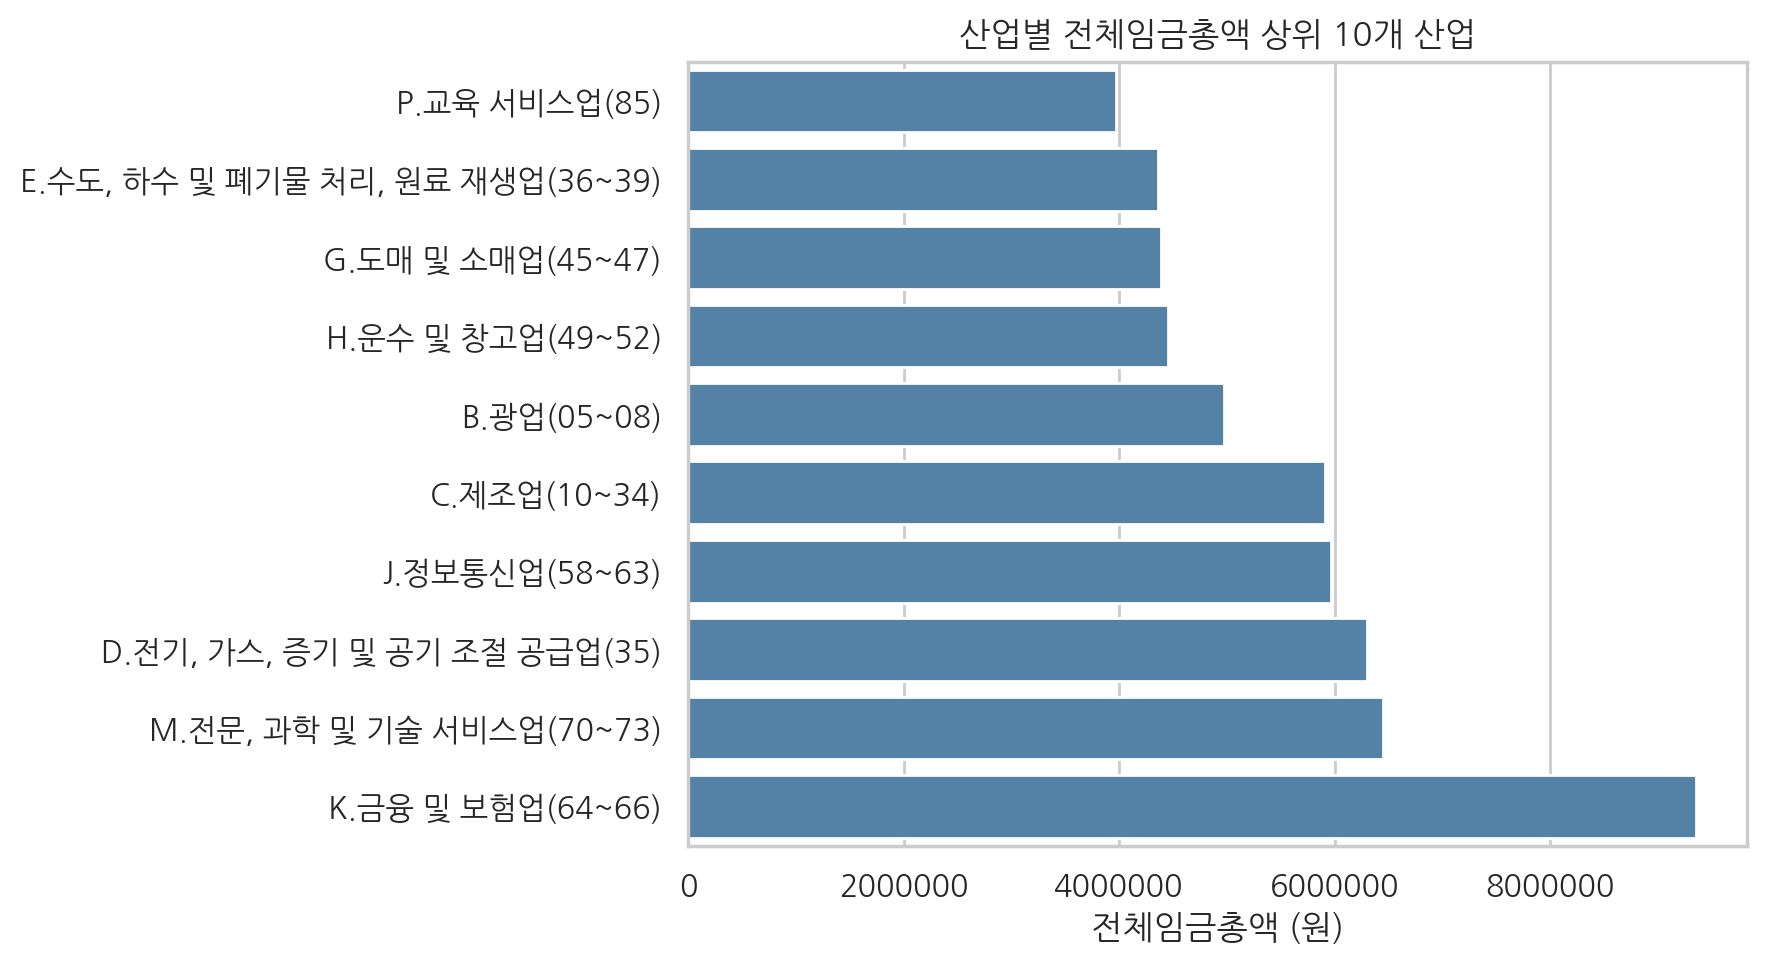

In [35]:
top10_wage = industry_summary.sort_values('전체임금총액 (원)', ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=top10_wage.sort_values('전체임금총액 (원)'),
    x='전체임금총액 (원)',
    y='산업분류',
    color='steelblue'
)
plt.title('산업별 전체임금총액 상위 10개 산업')
plt.xlabel('전체임금총액 (원)')
plt.ylabel('')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()


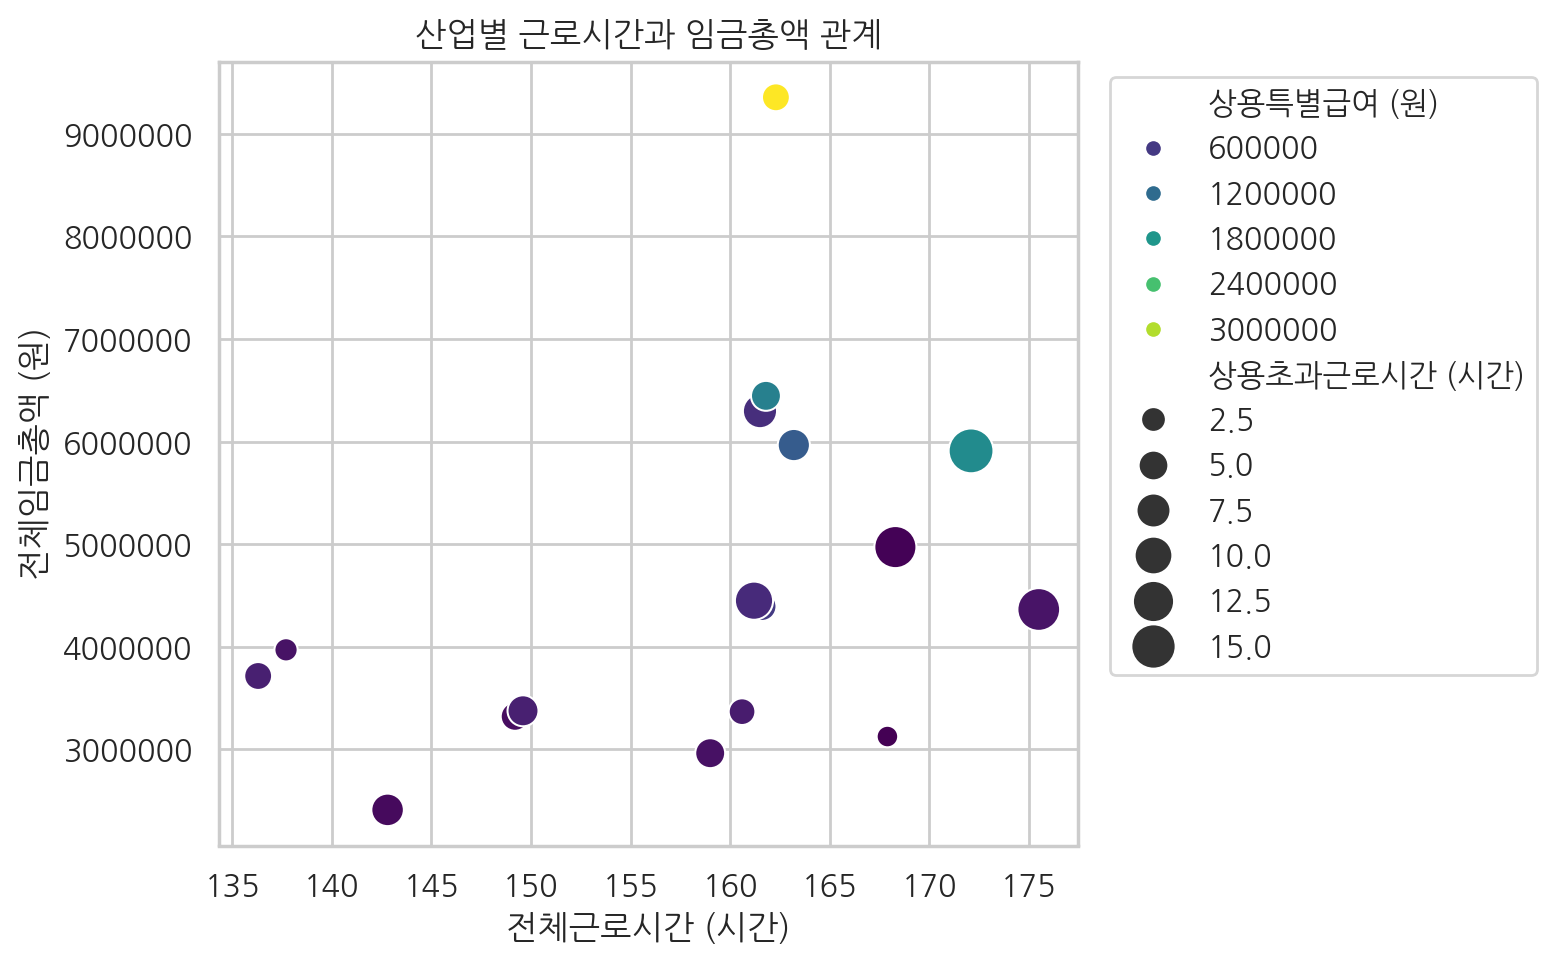

In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=industry_summary,
    x='전체근로시간 (시간)',
    y='전체임금총액 (원)',
    size='상용초과근로시간 (시간)',
    hue='상용특별급여 (원)',
    palette='viridis',
    sizes=(60, 260)
)
plt.title('산업별 근로시간과 임금총액 관계')
plt.xlabel('전체근로시간 (시간)')
plt.ylabel('전체임금총액 (원)')
plt.ticklabel_format(style='plain', axis='y')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. 규모별 비교

누적 구간이 아닌 실제 규모 구간(`1~4인`, `5~9인`, `10~29인`, `30~99인`, `100~299인`, `300인이상`)만 비교한다.

In [37]:
size_order = ['1~4인', '5~9인', '10~29인', '30~99인', '100~299인', '300인이상']

# 규모별 비교는 누적 구간이 아닌 실제 규모 구간만 남긴다.
size_df = df[(df['산업분류'] == '전체') & (df['규모별'].isin(size_order))].copy()
size_df['규모별'] = pd.Categorical(size_df['규모별'], categories=size_order, ordered=True)
size_df = size_df.sort_values('규모별')

base_wage = size_df.loc[size_df['규모별'] == '1~4인', '전체임금총액 (원)'].iloc[0]
size_df['임금_1~4인대비'] = size_df['전체임금총액 (원)'] / base_wage
size_df['특별급여비중(%)'] = size_df['상용특별급여 (원)'] / size_df['상용임금총액 (원)'] * 100

size_summary = size_df[[
    '규모별',
    '전체근로시간 (시간)',
    '상용초과근로시간 (시간)',
    '전체임금총액 (원)',
    '임금_1~4인대비',
    '상용정액급여 (원)',
    '상용초과급여 (원)',
    '상용특별급여 (원)',
    '특별급여비중(%)',
]]
size_summary


,규모별,전체근로시간 (시간),상용초과근로시간 (시간),전체임금총액 (원),임금_1~4인대비,상용정액급여 (원),상용초과급여 (원),상용특별급여 (원),특별급여비중(%)
8,1~4인,147.2,1.4,"2,783,256.0",1.0,"2,919,037.0","34,744.0","152,269.0",4.9
9,5~9인,155.6,3.1,"3,542,377.0",1.3,"3,414,544.0","79,136.0","259,609.0",6.9
10,10~29인,157.9,7.0,"3,873,780.0",1.4,"3,606,784.0","185,940.0","315,693.0",7.7
11,30~99인,163.2,10.6,"4,287,026.0",1.5,"3,839,118.0","287,530.0","319,326.0",7.2
12,100~299인,165.0,12.3,"4,921,602.0",1.8,"4,134,797.0","406,109.0","531,458.0",10.5
13,300인이상,162.6,10.7,"8,357,149.0",3.0,"4,895,687.0","472,866.0","3,247,032.0",37.7


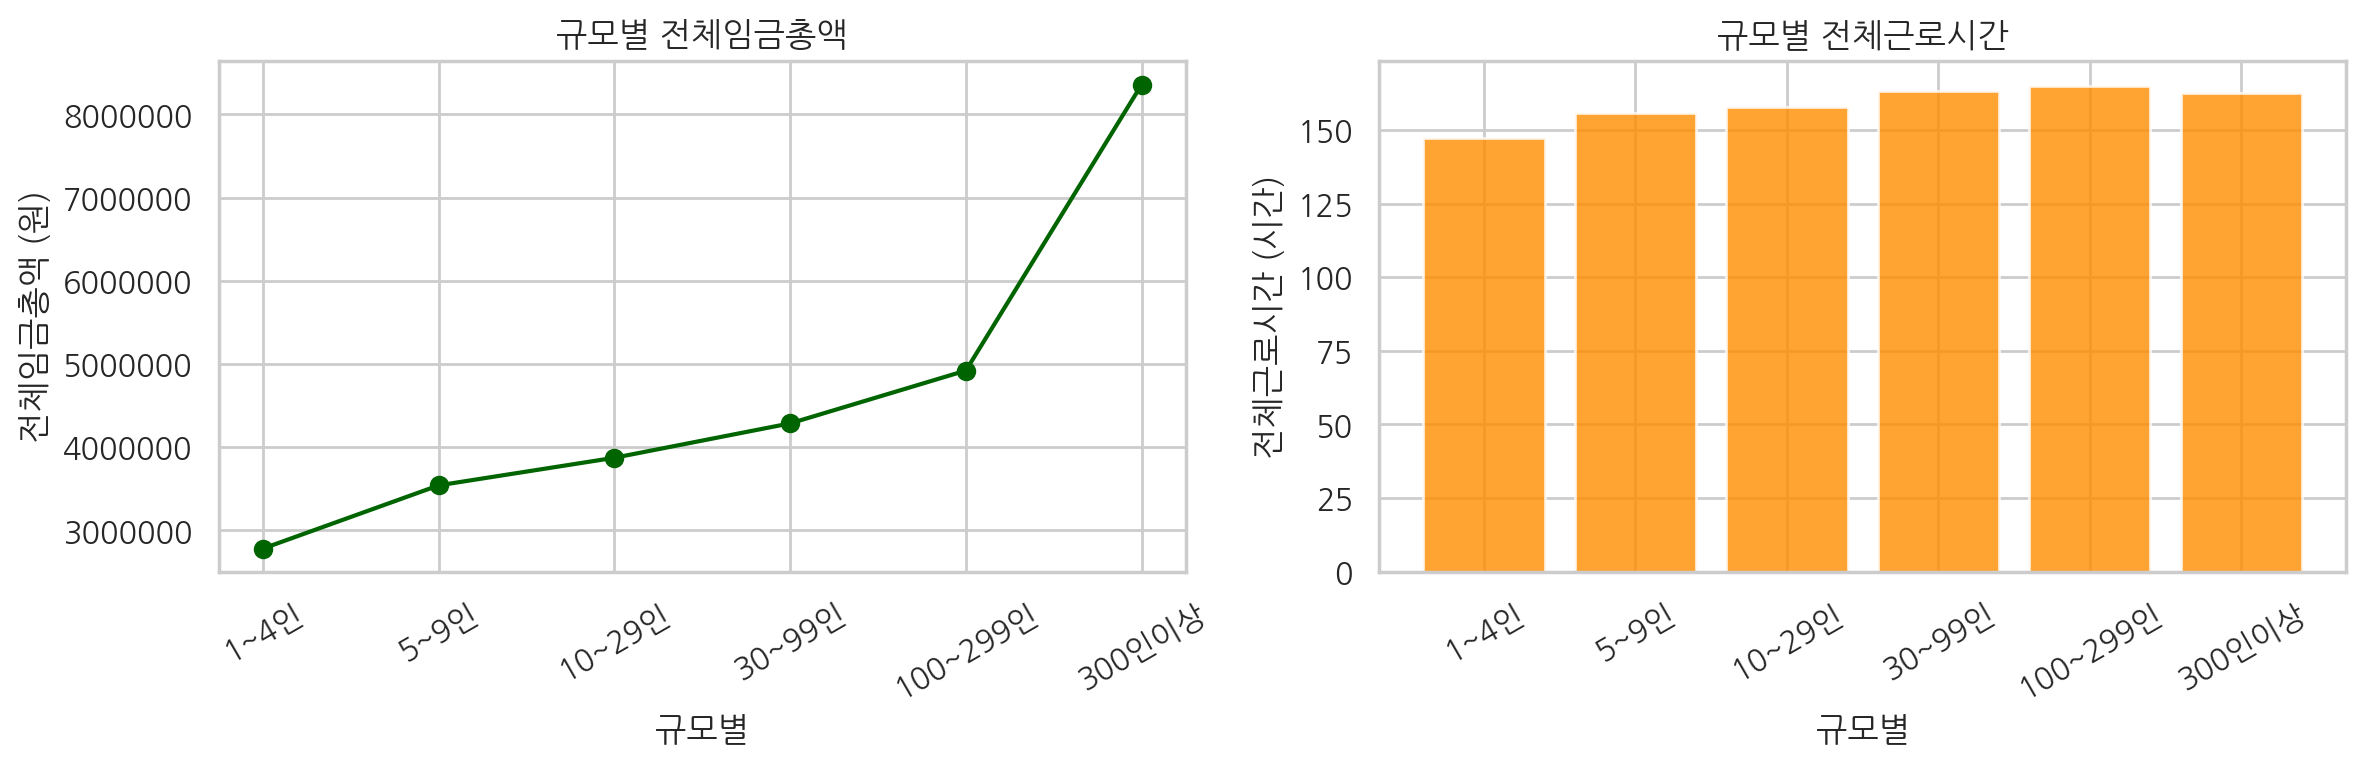

In [38]:
size_labels = size_df['규모별'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(size_labels, size_df['전체임금총액 (원)'], marker='o', color='darkgreen')
axes[0].set_title('규모별 전체임금총액')
axes[0].set_xlabel('규모별')
axes[0].set_ylabel('전체임금총액 (원)')
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(size_labels, size_df['전체근로시간 (시간)'], color='darkorange', alpha=.8)
axes[1].set_title('규모별 전체근로시간')
axes[1].set_xlabel('규모별')
axes[1].set_ylabel('전체근로시간 (시간)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 규모별 격차 해석

300인이상 사업체는 1~4인 사업체보다 임금총액이 약 3배 높다. 근로시간 차이는 15.4시간 정도이므로, 발표에서는 단순히 오래 일해서 임금이 높은 것이 아니라 특별급여와 임금 구성 차이가 격차를 키운다는 점을 강조한다.


In [39]:
gap_summary = size_summary[[
    '규모별',
    '전체근로시간 (시간)',
    '전체임금총액 (원)',
    '임금_1~4인대비',
    '상용특별급여 (원)',
    '특별급여비중(%)',
]].copy()

gap_summary


,규모별,전체근로시간 (시간),전체임금총액 (원),임금_1~4인대비,상용특별급여 (원),특별급여비중(%)
8,1~4인,147.2,"2,783,256.0",1.0,"152,269.0",4.9
9,5~9인,155.6,"3,542,377.0",1.3,"259,609.0",6.9
10,10~29인,157.9,"3,873,780.0",1.4,"315,693.0",7.7
11,30~99인,163.2,"4,287,026.0",1.5,"319,326.0",7.2
12,100~299인,165.0,"4,921,602.0",1.8,"531,458.0",10.5
13,300인이상,162.6,"8,357,149.0",3.0,"3,247,032.0",37.7


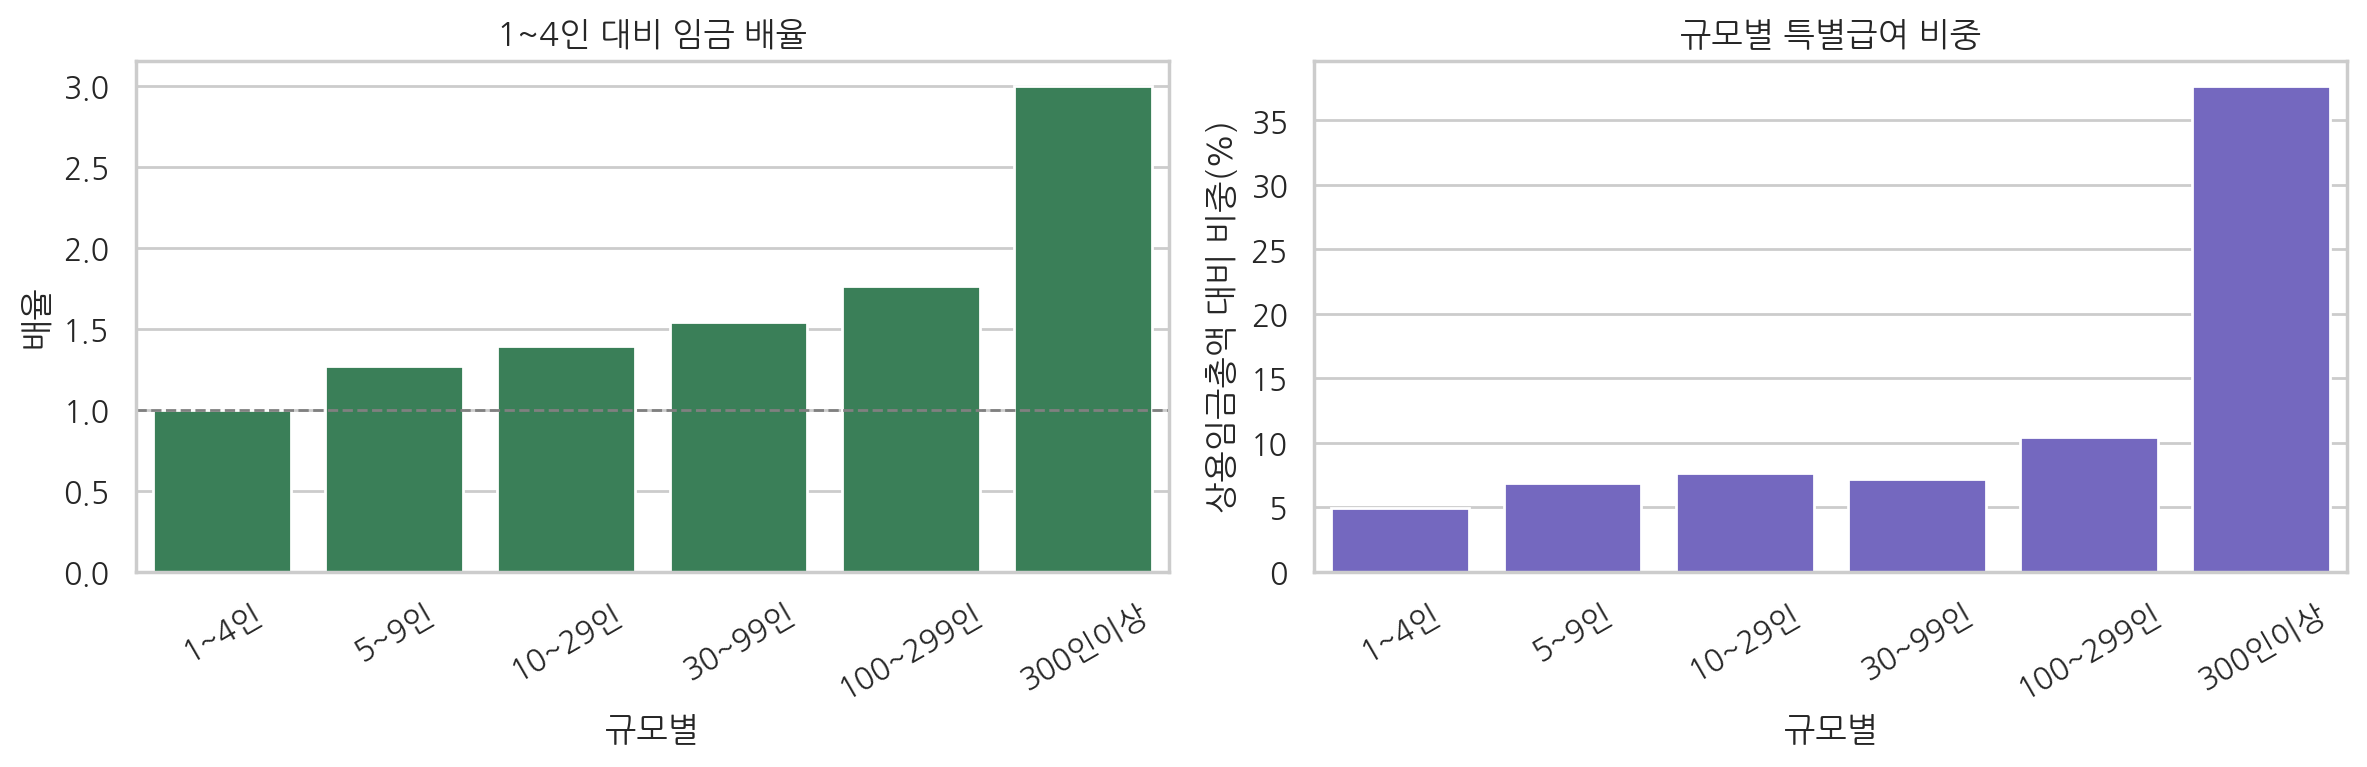

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=size_df,
    x='규모별',
    y='임금_1~4인대비',
    order=size_order,
    color='seagreen',
    ax=axes[0]
)
axes[0].axhline(1, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('1~4인 대비 임금 배율')
axes[0].set_xlabel('규모별')
axes[0].set_ylabel('배율')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(
    data=size_df,
    x='규모별',
    y='특별급여비중(%)',
    order=size_order,
    color='slateblue',
    ax=axes[1]
)
axes[1].set_title('규모별 특별급여 비중')
axes[1].set_xlabel('규모별')
axes[1].set_ylabel('상용임금총액 대비 비중(%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


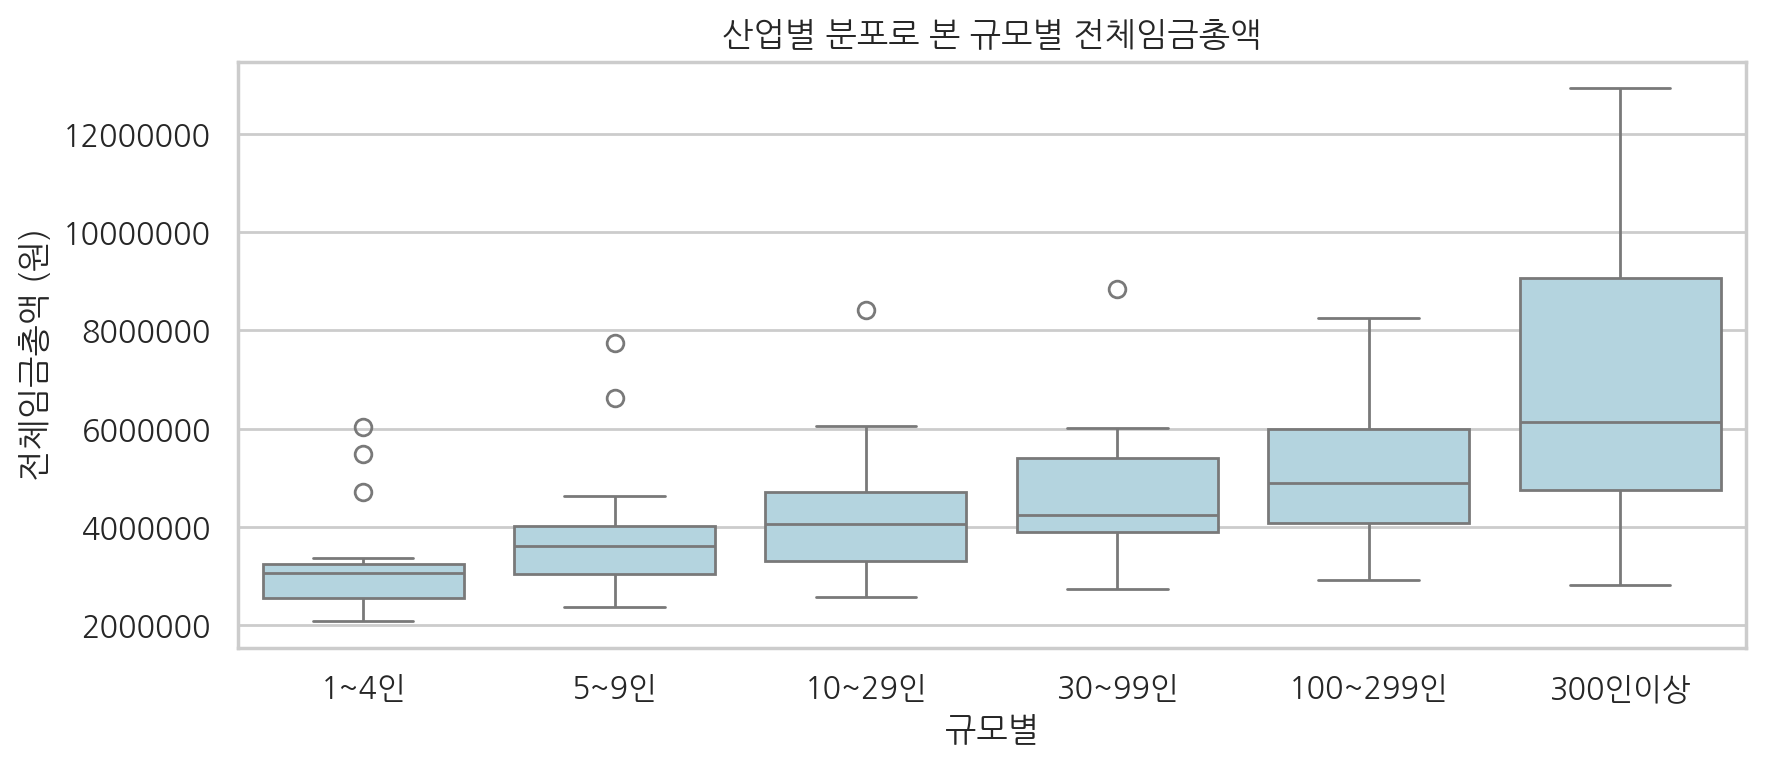

In [41]:
exact_industry_size_df = df[(df['산업분류'] != '전체') & (df['규모별'].isin(size_order))].copy()
exact_industry_size_df['규모별'] = pd.Categorical(
    exact_industry_size_df['규모별'],
    categories=size_order,
    ordered=True
)

plt.figure(figsize=(9, 4))
sns.boxplot(
    data=exact_industry_size_df,
    x='규모별',
    y='전체임금총액 (원)',
    order=size_order,
    color='lightblue'
)
plt.title('산업별 분포로 본 규모별 전체임금총액')
plt.xlabel('규모별')
plt.ylabel('전체임금총액 (원)')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()


## 6. 주요 지표 상관관계

상관계수와 히트맵으로 임금·근로시간 지표의 관계를 확인한다. 이 부분은 결론을 보조하는 자료이므로 발표 시간이 부족하면 간단히 넘어가도 된다.


In [42]:
corr = df[key_cols].corr()
corr


,전체근로시간 (시간),상용초과근로시간 (시간),전체임금총액 (원),상용정액급여 (원),상용초과급여 (원),상용특별급여 (원)
전체근로시간 (시간),1.0,0.6,0.4,0.3,0.6,0.2
상용초과근로시간 (시간),0.6,1.0,0.3,0.3,0.9,0.2
전체임금총액 (원),0.4,0.3,1.0,0.9,0.5,0.9
상용정액급여 (원),0.3,0.3,0.9,1.0,0.4,0.6
상용초과급여 (원),0.6,0.9,0.5,0.4,1.0,0.3
상용특별급여 (원),0.2,0.2,0.9,0.6,0.3,1.0


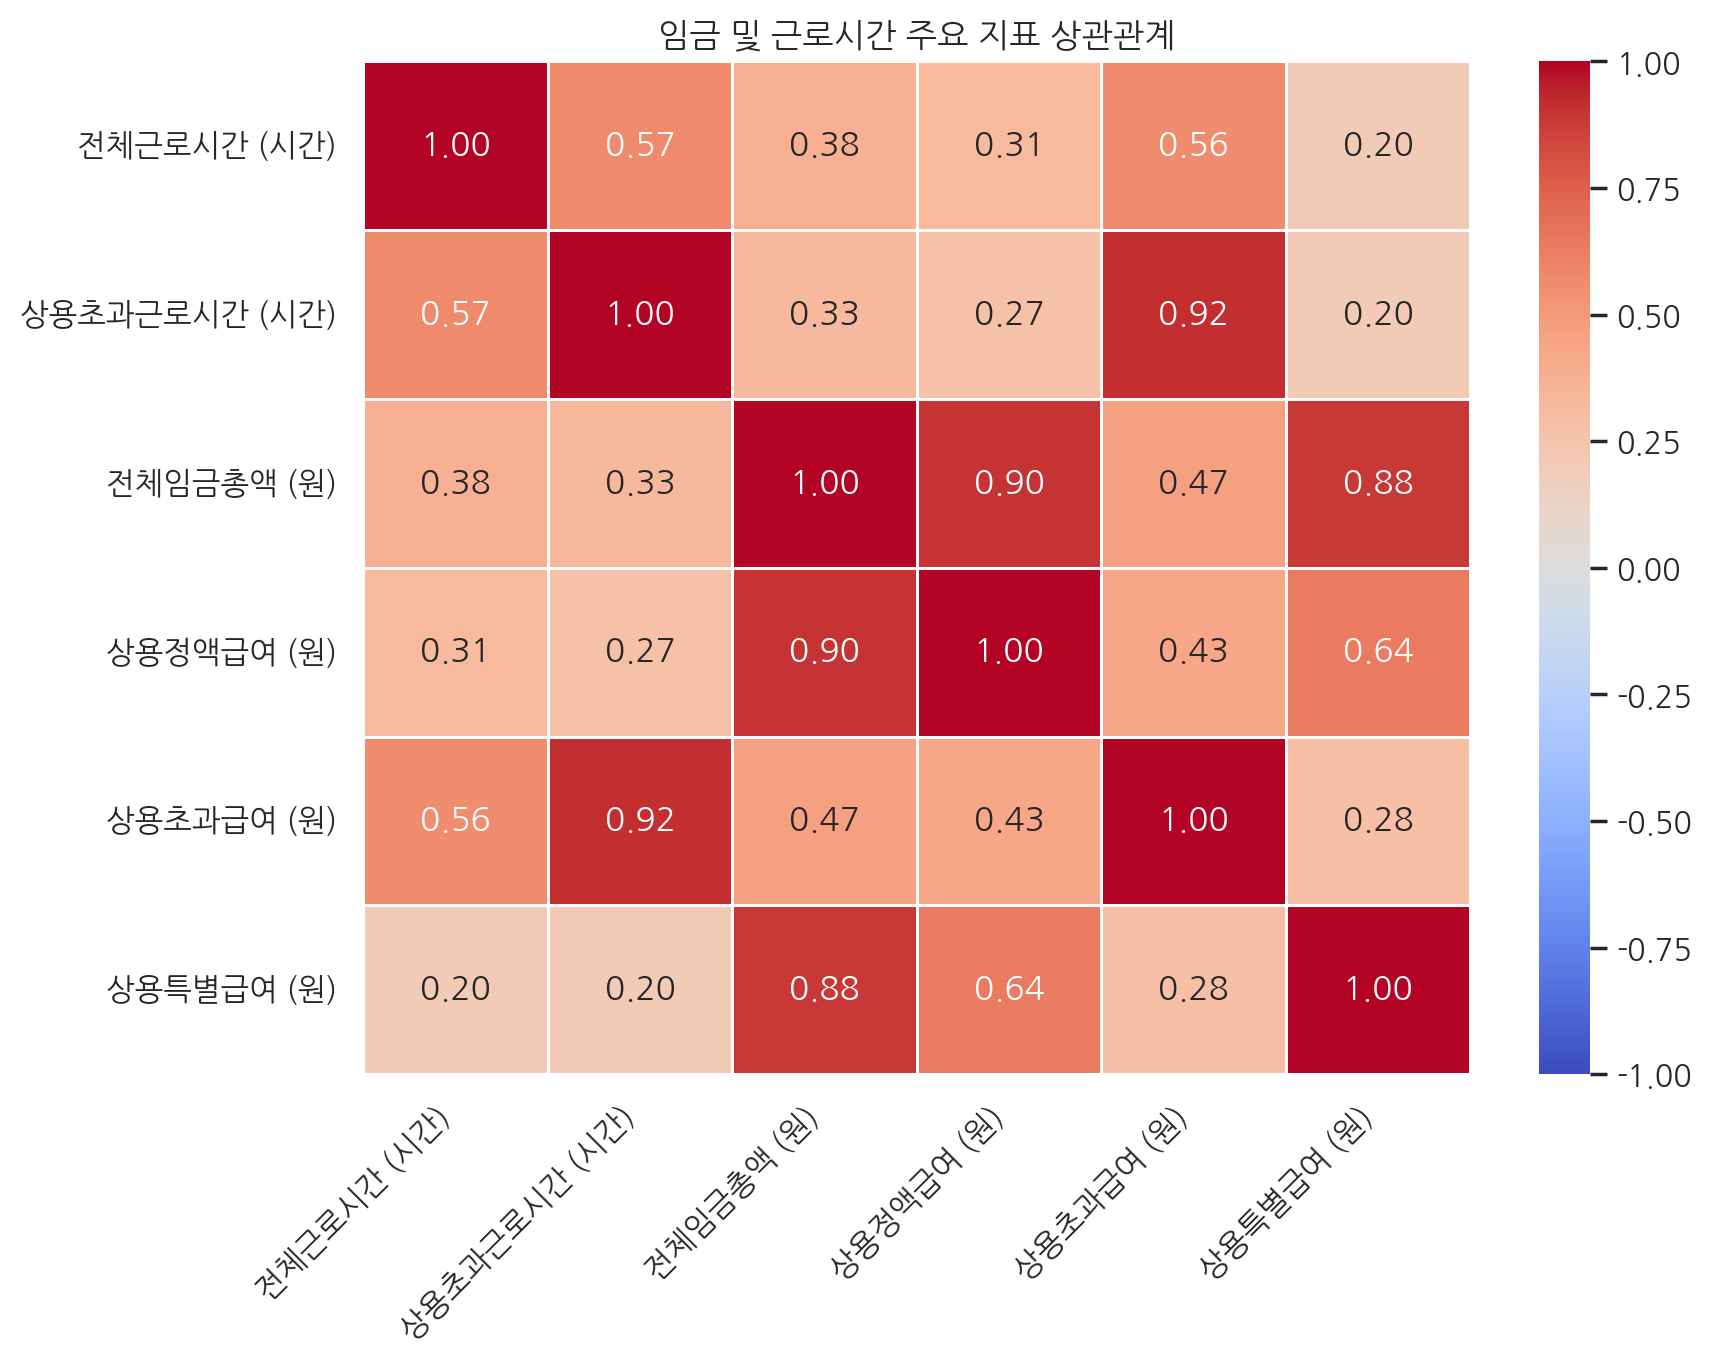

In [43]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=.5,
    fmt='.2f'
)
plt.title('임금 및 근로시간 주요 지표 상관관계')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 분석 요약

- 2026년 1월 전체 산업 전규모 기준 전체근로시간은 158.0시간, 전체임금총액은 4,588,273원이다.
- 산업별 전규모 기준 전체임금총액은 `K.금융 및 보험업`이 약 936만원으로 가장 높고, `I.숙박 및 음식점업`이 약 241만원으로 가장 낮다.
- 전체근로시간은 `E.수도, 하수 및 폐기물 처리, 원료 재생업`, `C.제조업`, `B.광업` 순으로 길지만, 근로시간이 길다고 항상 임금총액이 가장 높은 것은 아니다.
- 전체 산업 기준 300인이상 사업체의 전체임금총액은 약 836만원으로 1~4인 사업체 약 278만원의 약 3.0배이다.
- 300인이상 구간은 상용특별급여가 약 325만원으로 매우 높아 임금총액 격차를 키운다. 따라서 규모별 임금 격차는 근로시간 차이보다 임금 구성 차이의 영향이 더 커 보인다.
- 전체근로시간과 전체임금총액의 상관은 중간 이하이며, 전체임금총액은 상용정액급여와 상용특별급여와의 관계가 더 강하다.